In [ ]:
!pip -q install mediapipe opencv-python-headless imageio imageio-ffmpeg matplotlib
print("install done")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.7 MB/s eta 0:00:00
install done


In [ ]:
import json
import math
import os
import urllib.request

import cv2
import imageio
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

WORK_DIR = "/content/mediapipe_raccoon_python"
FRAME_DIR = f"{WORK_DIR}/driving_frames"
AVATAR_DIR = f"{WORK_DIR}/avatar_frames"
os.makedirs(FRAME_DIR, exist_ok=True)
os.makedirs(AVATAR_DIR, exist_ok=True)

RACCOON_GLB_PATH = f"{WORK_DIR}/raccoon_head.glb"
MP_TASK_PATH = f"{WORK_DIR}/face_landmarker.task"

if not os.path.exists(RACCOON_GLB_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-tasks/face_landmarker/raccoon_head.glb",
        RACCOON_GLB_PATH,
    )

if not os.path.exists(MP_TASK_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        MP_TASK_PATH,
    )

print("assets ready")

assets ready


In [ ]:
COMPONENT_DTYPES = {
    5120: np.int8,
    5121: np.uint8,
    5122: np.int16,
    5123: np.uint16,
    5125: np.uint32,
    5126: np.float32,
}

NUM_COMPONENTS = {
    "SCALAR": 1,
    "VEC2": 2,
    "VEC3": 3,
    "VEC4": 4,
    "MAT4": 16,
}


def read_accessor(gltf, blob, accessor_index):
    accessor = gltf["accessors"][accessor_index]
    buffer_view = gltf["bufferViews"][accessor["bufferView"]]
    dtype = COMPONENT_DTYPES[accessor["componentType"]]
    num_components = NUM_COMPONENTS[accessor["type"]]
    byte_offset = int(buffer_view.get("byteOffset", 0)) + int(accessor.get("byteOffset", 0))
    byte_stride = int(buffer_view.get("byteStride", 0))
    element_bytes = np.dtype(dtype).itemsize * num_components
    count = int(accessor["count"])

    if byte_offset < 0 or byte_offset > len(blob):
        raise ValueError(f"Invalid accessor offset {byte_offset} for buffer length {len(blob)}")

    if byte_stride and byte_stride != element_bytes:
        rows = []
        for idx in range(count):
            start = byte_offset + idx * byte_stride
            end = start + element_bytes
            chunk = blob[start:end]
            rows.append(np.frombuffer(chunk, dtype=dtype, count=num_components))
        array = np.stack(rows, axis=0).copy()
    else:
        raw_count = count * num_components
        array = np.frombuffer(blob, dtype=dtype, count=raw_count, offset=byte_offset).copy()
        array = array.reshape(count, num_components)

    if accessor.get("normalized", False):
        if dtype == np.int8:
            array = np.maximum(array / 127.0, -1.0)
        elif dtype == np.uint8:
            array = array / 255.0
        elif dtype == np.int16:
            array = np.maximum(array / 32767.0, -1.0)
        elif dtype == np.uint16:
            array = array / 65535.0
    return array


def quaternion_to_matrix(q):
    x, y, z, w = q
    xx, yy, zz = x * x, y * y, z * z
    xy, xz, yz = x * y, x * z, y * z
    wx, wy, wz = w * x, w * y, w * z
    return np.array(
        [
            [1 - 2 * (yy + zz), 2 * (xy - wz), 2 * (xz + wy), 0],
            [2 * (xy + wz), 1 - 2 * (xx + zz), 2 * (yz - wx), 0],
            [2 * (xz - wy), 2 * (yz + wx), 1 - 2 * (xx + yy), 0],
            [0, 0, 0, 1],
        ],
        dtype=np.float32,
    )


def node_transform_matrix(node):
    if node.get("matrix"):
        return np.array(node["matrix"], dtype=np.float32).reshape(4, 4).T

    mat = np.eye(4, dtype=np.float32)
    if node.get("translation"):
        mat[:3, 3] = np.array(node["translation"], dtype=np.float32)
    if node.get("rotation"):
        mat = mat @ quaternion_to_matrix(node["rotation"])
    if node.get("scale"):
        scale_mat = np.eye(4, dtype=np.float32)
        scale_mat[0, 0], scale_mat[1, 1], scale_mat[2, 2] = node["scale"]
        mat = mat @ scale_mat
    return mat


def load_glb_json_and_bin(glb_path):
    import struct

    with open(glb_path, "rb") as f:
        magic, version, length = struct.unpack("<III", f.read(12))
        assert magic == 0x46546C67, "Not a GLB file"

        json_length, json_type = struct.unpack("<II", f.read(8))
        assert json_type == 0x4E4F534A, "Missing JSON chunk"
        gltf = json.loads(f.read(json_length).decode("utf-8"))

        bin_length, bin_type = struct.unpack("<II", f.read(8))
        assert bin_type == 0x004E4942, "Missing BIN chunk"
        blob = f.read(bin_length)

    return gltf, blob


def load_raccoon_glb(glb_path):
    gltf, blob = load_glb_json_and_bin(glb_path)

    mesh_index = None
    primitive = None
    primitive_node = None
    for node in gltf["nodes"]:
        if "mesh" not in node:
            continue
        mesh = gltf["meshes"][node["mesh"]]
        for prim in mesh["primitives"]:
            if prim.get("targets"):
                mesh_index = node["mesh"]
                primitive = prim
                primitive_node = node
                break
        if primitive is not None:
            break

    assert primitive is not None, "No morph-target mesh found in raccoon GLB."

    mesh = gltf["meshes"][mesh_index]
    base_positions = read_accessor(gltf, blob, primitive["attributes"]["POSITION"]).astype(np.float32)
    faces = read_accessor(gltf, blob, primitive["indices"]).astype(np.int32).reshape(-1, 3)

    target_names = []
    if mesh.get("extras") and "targetNames" in mesh["extras"]:
        target_names = list(mesh["extras"]["targetNames"])
    elif primitive.get("extras") and "targetNames" in primitive["extras"]:
        target_names = list(primitive["extras"]["targetNames"])
    else:
        target_names = [f"target_{i}" for i in range(len(primitive["targets"]))]

    morph_deltas = {}
    for name, target in zip(target_names, primitive["targets"]):
        if "POSITION" not in target:
            continue
        morph_deltas[name] = read_accessor(gltf, blob, target["POSITION"]).astype(np.float32)

    node_matrix = node_transform_matrix(primitive_node)
    base_h = np.concatenate([base_positions, np.ones((len(base_positions), 1), dtype=np.float32)], axis=1)
    base_positions = (base_h @ node_matrix.T)[:, :3]

    return {
        "base_positions": base_positions,
        "faces": faces,
        "morph_deltas": morph_deltas,
        "target_names": target_names,
    }


def apply_blendshapes(base_positions, morph_deltas, blendshape_dict):
    vertices = base_positions.copy()
    for name, delta in morph_deltas.items():
        weight = float(blendshape_dict.get(name, 0.0))
        if weight != 0.0:
            vertices += delta * weight
    return vertices


def mediapipe_matrix_to_numpy(matrix_data):
    return np.array(matrix_data, dtype=np.float32).reshape(4, 4, order="F")


def transform_vertices(vertices, matrix_data, scale=160.0, z_offset=700.0):
    centered = vertices - vertices.mean(axis=0, keepdims=True)
    centered[:, 1] *= -1.0
    centered[:, 0] *= 1.0
    centered *= scale
    centered[:, 2] += z_offset
    return centered



def render_mesh(vertices, faces, image_size=512):
    canvas = np.full((image_size, image_size, 3), 248, dtype=np.uint8)

    tri_vertices = vertices[faces]
    valid = np.all(tri_vertices[:, :, 2] > 1.0, axis=1)
    tri_vertices = tri_vertices[valid]
    if len(tri_vertices) == 0:
        return canvas

    light_dir = np.array([0.35, 0.4, 1.0], dtype=np.float32)
    light_dir /= np.linalg.norm(light_dir)

    edges1 = tri_vertices[:, 1] - tri_vertices[:, 0]
    edges2 = tri_vertices[:, 2] - tri_vertices[:, 0]
    normals = np.cross(edges1, edges2)
    normal_norm = np.linalg.norm(normals, axis=1, keepdims=True) + 1e-8
    normals = normals / normal_norm

    intensities = np.clip(0.45 + 0.55 * np.abs(normals @ light_dir), 0.0, 1.0)
    depths = tri_vertices[:, :, 2].mean(axis=1)
    order = np.argsort(depths)[::-1]

    fx = fy = image_size * 1.35
    cx = cy = image_size / 2.0

    base_color = np.array([146, 116, 90], dtype=np.float32)

    for idx in order:
        tri = tri_vertices[idx]
        proj = np.zeros((3, 2), dtype=np.float32)
        proj[:, 0] = fx * (tri[:, 0] / tri[:, 2]) + cx
        proj[:, 1] = fy * (-tri[:, 1] / tri[:, 2]) + cy

        poly = np.round(proj).astype(np.int32)
        if cv2.contourArea(poly) < 1.0:
            continue

        shade = intensities[idx]
        color = np.clip(base_color * shade, 0, 255).astype(np.uint8).tolist()
        cv2.fillConvexPoly(canvas, poly, color, lineType=cv2.LINE_AA)
        cv2.polylines(canvas, [poly], True, (52, 38, 28), 1, lineType=cv2.LINE_AA)

    return canvas


print("helpers ready")


helpers ready


In [ ]:
print("Upload driving video")
upload = files.upload()
DRIVING_PATH = next(iter(upload.keys()))

Upload driving video


Saving d0.mp4 to d0.mp4


In [ ]:
base_options = python.BaseOptions(model_asset_path=MP_TASK_PATH)
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_faces=1,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
)
detector = vision.FaceLandmarker.create_from_options(options)

raccoon_asset = load_raccoon_glb(RACCOON_GLB_PATH)
print("target count:", len(raccoon_asset["target_names"]))
print("sample targets:", raccoon_asset["target_names"][:12])

target count: 52
sample targets: ['eyeBlinkLeft', 'eyeLookDownLeft', 'eyeLookInLeft', 'eyeLookOutLeft', 'eyeLookUpLeft', 'eyeSquintLeft', 'eyeWideLeft', 'eyeBlinkRight', 'eyeLookDownRight', 'eyeLookInRight', 'eyeLookOutRight', 'eyeLookUpRight']


In [ ]:
cap = cv2.VideoCapture(DRIVING_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("driving frames:", frame_count, "fps:", fps)

records = []
frame_index = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break

    frame_path = f"{FRAME_DIR}/frame_{frame_index:05d}.png"
    cv2.imwrite(frame_path, frame)

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = detector.detect_for_video(mp_image, int(frame_index * 1000 / fps))

    record = {
        "frame_index": frame_index,
        "frame_path": frame_path,
        "has_face": False,
    }

    if result.face_blendshapes and result.facial_transformation_matrixes:
        blendshape_dict = {
            item.category_name: float(item.score)
            for item in result.face_blendshapes[0]
        }
        matrix = np.array(result.facial_transformation_matrixes[0], dtype=np.float32)
        record["has_face"] = True
        record["blendshapes"] = blendshape_dict
        record["matrix"] = matrix.tolist()

    records.append(record)
    frame_index += 1

    if frame_index % 25 == 0:
        print("processed", frame_index)

cap.release()

with open(f"{WORK_DIR}/driving_signals.json", "w", encoding="utf-8") as f:
    json.dump({"fps": fps, "records": records}, f, ensure_ascii=False, indent=2)

print("signals saved:", f"{WORK_DIR}/driving_signals.json")


driving frames: 78 fps: 25.0
processed 25
processed 50
processed 75
signals saved: /content/mediapipe_raccoon_python/driving_signals.json


In [ ]:
avatar_paths = []
side_by_side_paths = []

base_positions = raccoon_asset["base_positions"]
faces = raccoon_asset["faces"]
morph_deltas = raccoon_asset["morph_deltas"]

for record in records:
    driving_frame = cv2.imread(record["frame_path"])
    avatar_frame = np.full((512, 512, 3), 248, dtype=np.uint8)

    if record["has_face"]:
        morphed = apply_blendshapes(base_positions, morph_deltas, record["blendshapes"])
        transformed = transform_vertices(morphed, record["matrix"], scale=42.0, z_offset=240.0)
        avatar_frame = render_mesh(transformed, faces, image_size=512)

    avatar_path = f"{AVATAR_DIR}/avatar_{record['frame_index']:05d}.png"
    cv2.imwrite(avatar_path, avatar_frame)
    avatar_paths.append(avatar_path)

    driving_resized = cv2.resize(driving_frame, (512, 512))
    combined = np.concatenate([driving_resized, avatar_frame], axis=1)
    side_path = f"{WORK_DIR}/side_{record['frame_index']:05d}.png"
    cv2.imwrite(side_path, combined)
    side_by_side_paths.append(side_path)

    if (record["frame_index"] + 1) % 25 == 0:
        print("rendered", record["frame_index"] + 1)


rendered 25
rendered 50
rendered 75


In [ ]:
AVATAR_VIDEO = f"{WORK_DIR}/raccoon_avatar_only.mp4"
SIDE_VIDEO = f"{WORK_DIR}/raccoon_avatar_side_by_side.mp4"

writer = imageio.get_writer(AVATAR_VIDEO, fps=fps)
for path in avatar_paths:
    frame = cv2.imread(path)
    writer.append_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
writer.close()

writer = imageio.get_writer(SIDE_VIDEO, fps=fps)
for path in side_by_side_paths:
    frame = cv2.imread(path)
    writer.append_data(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
writer.close()

print("saved:", AVATAR_VIDEO)
print("saved:", SIDE_VIDEO)
files.download(SIDE_VIDEO)


saved: /content/mediapipe_raccoon_python/raccoon_avatar_only.mp4
saved: /content/mediapipe_raccoon_python/raccoon_avatar_side_by_side.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

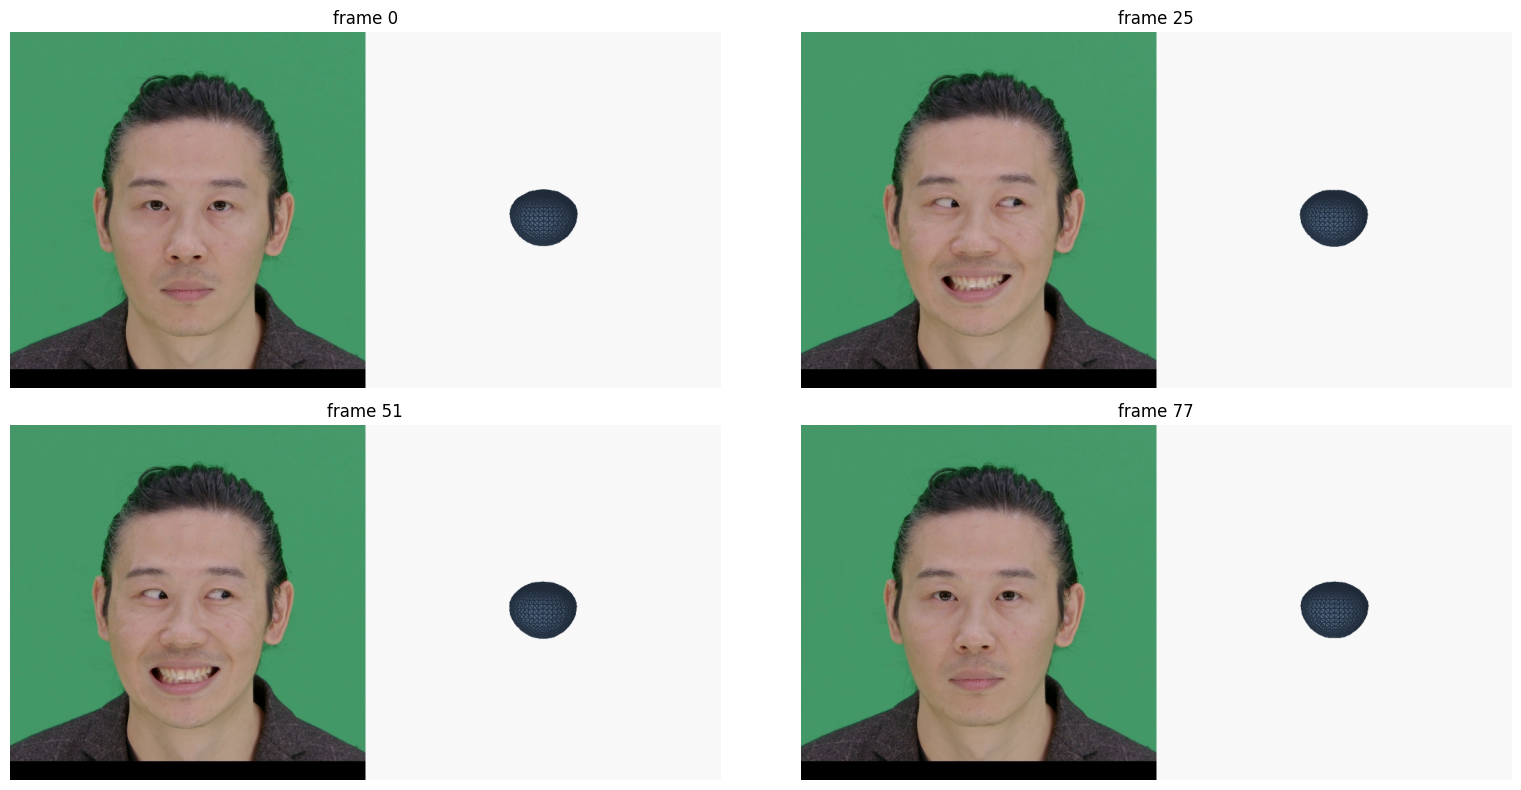

In [ ]:
sample_ids = np.linspace(0, len(side_by_side_paths) - 1, num=min(4, len(side_by_side_paths)), dtype=int)
plt.figure(figsize=(16, 8))
for i, idx in enumerate(sample_ids, 1):
    frame = cv2.imread(side_by_side_paths[idx])
    plt.subplot(2, 2, i)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"frame {idx}")
plt.tight_layout()
plt.show()
